# Hybrid multi-run comparison (correct throughput + true p99 + hot partition)

Why hybrid?
- **Per-message latency files** are *sampled* (not every message is logged). Counting rows there underestimates throughput.
- **consumer_metrics_run-*.csv** contains correct windowed counts/rates → use it for throughput, violation rate, and per-pod p99.
- **Per-message files** contain `partition` → use them for **true p99 (sampled estimate)** and **hot partition** metrics.

This notebook produces **line plots by t_bucket (30s)** comparing several runs, using your real folder layout:
```
results/<run>/consumer/pipeline-configmap.yaml
results/<run>/consumer/consumer-sts-*_metrics/consumer_metrics_run-*.csv
results/<run>/consumer/consumer-sts-*_metrics/per_message_latency_run-*.csv
```

Outputs (in `comparison_out/`):
- `hybrid_timeseries_long.csv`
- `hybrid_summary.csv`
- PDF plots: throughput, p99 (pods max), SLA violation, lag skew ratio, true p99 (sampled), hot-partition p99


In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Any, Dict, Optional, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
RESULTS_ROOT = Path('../results').resolve()   # change if needed
OUT_DIR = Path('./comparison_out').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

BUCKET_SEC = 30
SLA_MS = 800

# Optional run selection
RUN_FILTER_REGEX = None  # e.g. r'.*_skew$' or r'.*20260223.*'

print('RESULTS_ROOT =', RESULTS_ROOT)
print('OUT_DIR      =', OUT_DIR)


RESULTS_ROOT = /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results
OUT_DIR      = /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out


In [2]:
# =========================
# Helpers
# =========================
def safe_float(x: Any) -> Optional[float]:
    try:
        if x is None:
            return None
        if isinstance(x, str) and x.strip() == '':
            return None
        return float(x)
    except Exception:
        return None

def read_configmap_params(cfg_path: Path) -> Dict[str, Any]:
    """Minimal parsing for ConfigMap YAML values under `data:`."""
    params = {'traffic_mode': 'unknown', 'skew_fraction': None, 'skew_partitions': None}
    if not cfg_path.exists():
        return params

    in_data = False
    for raw in cfg_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        line = raw.rstrip('\n')
        if re.match(r'^\s*data\s*:\s*$', line):
            in_data = True
            continue
        if in_data and re.match(r'^\S', line):
            in_data = False
        if not in_data:
            continue

        m = re.match(r'^\s*([A-Za-z0-9_]+)\s*:\s*(.*)\s*$', line)
        if not m:
            continue
        k = m.group(1).strip()
        v = m.group(2).strip().strip('"').strip("'")

        if k == 'TRAFFIC_MODE':
            params['traffic_mode'] = (v or 'unknown').lower()
        elif k in ('SKEW_FRACTION','SKEW_FRAC','SKEWFRAC'):
            params['skew_fraction'] = safe_float(v)
        elif k in ('SKEW_PARTITIONS','SKEW_PARTITION','SKEW_PARTS'):
            nums = re.findall(r'-?\d+', v)
            params['skew_partitions'] = ','.join(nums) if nums else v
    return params

def extract_consumer_pod_from_name(fname: str) -> str:
    m = re.search(r'(consumer-sts-\d+)', fname)
    return m.group(1) if m else 'unknown'

def auto_to_seconds(ts: pd.Series) -> pd.Series:
    """Convert epoch timestamps to seconds if they look like ms."""
    ts = pd.to_numeric(ts, errors='coerce')
    med = ts.dropna().median()
    if pd.isna(med):
        return ts
    return ts / 1000.0 if float(med) > 1e11 else ts


In [3]:
# =========================
# Loaders
# =========================
def load_consumer_metrics_run(run_dir: Path) -> pd.DataFrame:
    """Load all consumer_metrics_run-*.csv across consumer pods for a run.

    This is the **preferred** source for throughput/violation/pod-p99 over time.
    """
    consumer_dir = run_dir / 'consumer'
    files = sorted(consumer_dir.glob('consumer-sts-*_metrics/consumer_metrics_run-*.csv'))
    if not files:
        return pd.DataFrame()

    # Debug: how many files
    # print('[DBG] per-message files:', len(files), 'example:', files[0].name)

    # Debug: how many files
    # print('[DBG] consumer_metrics files:', len(files), 'example:', files[0].name)

    frames = []
    for f in files:
        df = pd.read_csv(f)
        df['pod'] = extract_consumer_pod_from_name(f.name)
        df['__file'] = str(f)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

def load_cluster_agg(run_dir: Path) -> pd.DataFrame:
    """Fallback: load cluster_agg_*.csv (already aggregated by time bucket)."""
    consumer_dir = run_dir / 'consumer'
    files = sorted(consumer_dir.glob('cluster_agg_*.csv'))
    if not files:
        return pd.DataFrame()

    # Debug: how many files
    # print('[DBG] consumer_metrics files:', len(files), 'example:', files[0].name)
    df = pd.read_csv(files[0])
    df['__file'] = str(files[0])
    return df

def load_per_pod_merged(run_dir: Path) -> pd.DataFrame:
    """Fallback: load per_pod_merged_*.csv (per-pod time buckets)."""
    consumer_dir = run_dir / 'consumer'
    files = sorted(consumer_dir.glob('per_pod_merged_*.csv'))
    if not files:
        return pd.DataFrame()

    # Debug: how many files
    # print('[DBG] consumer_metrics files:', len(files), 'example:', files[0].name)
    df = pd.read_csv(files[0])
    df['__file'] = str(files[0])
    return df

def load_per_message_run(run_dir: Path) -> pd.DataFrame:
    """Load all per-message files across consumer pods for a run.

    NOTE: This is usually **sampled**, so do NOT use it to compute throughput.
    Use it for:
      - true p99 (sampled estimate)
      - hot partition
      - hot partition p99 over time
    """
    consumer_dir = run_dir / 'consumer'
    files = sorted(consumer_dir.glob('consumer-sts-*_metrics/per_message_latency_run-*.csv'))
    if not files:
        return pd.DataFrame()

    # Debug: how many files
    # print('[DBG] consumer_metrics files:', len(files), 'example:', files[0].name)

    frames = []
    for f in files:
        df = pd.read_csv(f)
        if 'recv_ts' not in df.columns or 'e2e_ms' not in df.columns or 'partition' not in df.columns:
            raise ValueError(f'{f} missing required columns (recv_ts, e2e_ms, partition)')
        df['consumer_pod'] = extract_consumer_pod_from_name(f.name)
        df['__file'] = str(f)
        frames.append(df)

    lat = pd.concat(frames, ignore_index=True)
    lat['recv_ts'] = pd.to_numeric(lat['recv_ts'], errors='coerce')
    lat['e2e_ms'] = pd.to_numeric(lat['e2e_ms'], errors='coerce')
    lat['partition'] = pd.to_numeric(lat['partition'], errors='coerce').astype('Int64')
    lat = lat.dropna(subset=['recv_ts','e2e_ms','partition'])
    return lat


In [4]:
# =========================
# Build run time-series (truth for throughput)
# =========================
def build_ts_truth(run_dir: Path, bucket_sec: int, expected_pods: Optional[int] = None) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Return (cluster_ts, pod_summary) using the best available source.

    Priority:
      1) consumer_metrics_run-*.csv (preferred)
      2) cluster_agg_*.csv
      3) per_pod_merged_*.csv (aggregate to cluster)

    Output columns (when available):
      - t_bucket
      - throughput (msg/s)
      - p99_pods_max_ms
      - p99_pods_med_ms
      - viol_rate
      - lag_skew_ratio
    """
    # 1) Preferred: consumer_metrics_run
    m = load_consumer_metrics_run(run_dir)
    if not m.empty:
        # numeric normalization
        for c in ['uptime_sec','msg_rate_window','lat_p99_ms','window_total','window_viol','viol_rate','lag_skew_ratio']:
            if c in m.columns:
                m[c] = pd.to_numeric(m[c], errors='coerce')

        if 'uptime_sec' not in m.columns:
            raise ValueError('consumer_metrics missing uptime_sec')

        m = m.dropna(subset=['uptime_sec']).copy()
        # Normalize uptime to be run-relative. Some runs keep the consumer process alive across experiments,
        # so `uptime_sec` can start at a large value. Using a relative clock makes time-series comparable.
        u0 = float(m['uptime_sec'].min())
        m['uptime_rel_sec'] = m['uptime_sec'] - u0
        # Bucket-index alignment: use an integer bucket index as the canonical clock.
        # This avoids mismatches when merging with per-message buckets.
        m['bucket_idx'] = np.floor(m['uptime_rel_sec'] / bucket_sec).astype(int)
        m['t_bucket'] = m['bucket_idx'] * bucket_sec

        grp = m.groupby('t_bucket', dropna=True)
        out = pd.DataFrame({'t_bucket': sorted(grp.groups.keys())})

        if 'msg_rate_window' in m.columns:
            out['throughput'] = grp['msg_rate_window'].sum(min_count=1)

        if 'lat_p99_ms' in m.columns:
            out['p99_pods_max_ms'] = grp['lat_p99_ms'].max()
            out['p99_pods_med_ms'] = grp['lat_p99_ms'].median()

        if 'window_total' in m.columns and 'window_viol' in m.columns:
            tot = grp['window_total'].sum(min_count=1)
            vio = grp['window_viol'].sum(min_count=1)
            out['viol_rate_true_window'] = (vio / tot).replace([np.inf, -np.inf], np.nan)
            out['viol_rate'] = out['viol_rate_true_window']
        elif 'viol_rate' in m.columns:
            out['viol_rate'] = grp['viol_rate'].mean()

        if 'lag_skew_ratio' in m.columns:
            out['lag_skew_ratio'] = grp['lag_skew_ratio'].mean()

        # How many consumer pods contributed to this bucket?
        if 'pod' in m.columns:
            out['pods_active'] = grp['pod'].nunique()
            if expected_pods is not None:
                out = out[out['pods_active'] == expected_pods].copy()

        out = out.sort_values('t_bucket').reset_index(drop=True)

        pod_summary = {}
        if 'lat_p99_ms' in m.columns and 'pod' in m.columns:
            s = m.groupby('pod')['lat_p99_ms'].mean().dropna().sort_values(ascending=False)
            if len(s) > 0:
                pod_summary['hot_consumer'] = str(s.index[0])
                pod_summary['hot_consumer_p99_mean_ms'] = float(s.iloc[0])

        pod_summary['truth_source'] = 'consumer_metrics_run'
        return out, pod_summary

    # 2) Fallback: cluster_agg
    ca = load_cluster_agg(run_dir)
    if not ca.empty:
        # try to normalize time column to t_bucket
        for tcol in ['t_bucket','window_start_s','bucket_s','t']:
            if tcol in ca.columns and tcol != 't_bucket':
                ca = ca.rename(columns={tcol:'t_bucket'})
        ca['t_bucket'] = pd.to_numeric(ca.get('t_bucket', np.nan), errors='coerce')

        out = pd.DataFrame({'t_bucket': ca['t_bucket']})
        for c in ['throughput','p99_max','p99_med','viol_rate','skew_ratio']:
            if c in ca.columns:
                out[c] = pd.to_numeric(ca[c], errors='coerce')
        # map names to our standard columns
        if 'p99_max' in out.columns:
            out = out.rename(columns={'p99_max':'p99_pods_max_ms'})
        if 'p99_med' in out.columns:
            out = out.rename(columns={'p99_med':'p99_pods_med_ms'})
        if 'skew_ratio' in out.columns and 'lag_skew_ratio' not in out.columns:
            out = out.rename(columns={'skew_ratio':'lag_skew_ratio'})

        out = out.dropna(subset=['t_bucket']).sort_values('t_bucket').reset_index(drop=True)
        summ = {'truth_source':'cluster_agg'}
        return out, summ

    # 3) Fallback: per_pod_merged -> aggregate to cluster
    pp = load_per_pod_merged(run_dir)
    if not pp.empty:
        # normalize time
        tcol = None
        for c in ['t_bucket','window_start_s','bucket_s','t']:
            if c in pp.columns:
                tcol = c
                break
        if tcol is None:
            raise ValueError('per_pod_merged has no recognizable time column')
        pp[tcol] = pd.to_numeric(pp[tcol], errors='coerce')
        pp = pp.dropna(subset=[tcol]).copy()
        pp['t_bucket'] = pp[tcol].astype(int)

        # candidates
        thr_col = 'msg_rate_window' if 'msg_rate_window' in pp.columns else ('throughput' if 'throughput' in pp.columns else None)
        p99_col = 'lat_p99_ms' if 'lat_p99_ms' in pp.columns else ('true_p99_ms' if 'true_p99_ms' in pp.columns else None)
        vio_col = 'viol_rate' if 'viol_rate' in pp.columns else None
        skw_col = 'lag_skew_ratio' if 'lag_skew_ratio' in pp.columns else ('skew_ratio' if 'skew_ratio' in pp.columns else None)

        g = pp.groupby('t_bucket', dropna=True)
        out = pd.DataFrame({'t_bucket': sorted(g.groups.keys())})
        if thr_col:
            out['throughput'] = g[thr_col].sum(min_count=1)
        if p99_col:
            out['p99_pods_max_ms'] = g[p99_col].max()
            out['p99_pods_med_ms'] = g[p99_col].median()
        if vio_col:
            out['viol_rate'] = g[vio_col].mean()
        if skw_col:
            out['lag_skew_ratio'] = g[skw_col].mean()

        out = out.sort_values('t_bucket').reset_index(drop=True)
        summ = {'truth_source':'per_pod_merged'}
        return out, summ

    return pd.DataFrame(), {'truth_source':'none'}


In [5]:
# =========================
# Hot partition + true p99 (sampled) from per-message files
# =========================
def build_partition_metrics_from_permsg(lat: pd.DataFrame, bucket_sec: int, sla_ms: float) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Return (permsg_ts, part_summary).

    permsg_ts columns:
      t_bucket, true_p99_ms, true_max_ms, true_viol_rate, hot_part_p99_ms
    """
    if lat.empty:
        return pd.DataFrame(), {'hot_partition': None, 'hot_partition_p99_mean_ms': None, 'skew_ratio_overall': None}

    lat = lat.copy()
    recv_sec = auto_to_seconds(lat['recv_ts'])
    t0 = float(recv_sec.min())
    lat['bucket_idx'] = np.floor((recv_sec - t0) / bucket_sec).astype(int)
    lat['t_bucket'] = lat['bucket_idx'] * bucket_sec

    # hot partition: by total count
    counts = lat.groupby('partition').size().sort_values(ascending=False)
    hot_part = int(counts.index[0]) if len(counts) else None

    # overall skew ratio by counts
    skew_overall = None
    if len(counts) > 0 and float(counts.mean()) > 0:
        skew_overall = float(counts.max() / counts.mean())

    def bucket_stats(g: pd.DataFrame) -> pd.Series:
        arr = g['e2e_ms'].to_numpy()
        return pd.Series({
            'true_p99_ms': float(np.quantile(arr, 0.99)) if len(arr) else np.nan,
            'true_max_ms': float(np.max(arr)) if len(arr) else np.nan,
            'true_viol_rate': float(np.mean(arr > sla_ms)) if len(arr) else np.nan,
        })

    ts = lat.groupby('t_bucket').apply(bucket_stats).reset_index().sort_values('t_bucket').reset_index(drop=True)

    # hot partition p99 per bucket
    hot_p99_mean = None
    if hot_part is not None:
        hp = lat[lat['partition'] == hot_part]
        if not hp.empty:
            def hp_p99(g: pd.DataFrame) -> pd.Series:
                arr = g['e2e_ms'].to_numpy()
                return pd.Series({'hot_part_p99_ms': float(np.quantile(arr, 0.99)) if len(arr) else np.nan})
            hp_ts = hp.groupby('t_bucket').apply(hp_p99).reset_index()
            ts = ts.merge(hp_ts, on='t_bucket', how='left')
            v = ts['hot_part_p99_ms'].dropna()
            if len(v) > 0:
                hot_p99_mean = float(v.mean())

    part_summary = {
        'hot_partition': hot_part,
        'hot_partition_p99_mean_ms': hot_p99_mean,
        'permsg_skew_ratio_overall': skew_overall,
        'permsg_n_samples': int(len(lat)),
    }
    return ts, part_summary


In [6]:
# =========================
# Load all runs and build hybrid tables
# =========================
run_dirs = sorted([p for p in RESULTS_ROOT.iterdir() if p.is_dir() and (p/'consumer').exists()])
if RUN_FILTER_REGEX:
    pat = re.compile(RUN_FILTER_REGEX)
    run_dirs = [p for p in run_dirs if pat.search(p.name)]

all_ts = []
all_rows = []

for rd in run_dirs:
    cfg = read_configmap_params(rd / 'consumer' / 'pipeline-configmap.yaml')
    tm = cfg.get('traffic_mode','unknown')
    sf = cfg.get('skew_fraction', None)
    sp = cfg.get('skew_partitions', None)
    sf_s = f"{sf:.2f}" if isinstance(sf,(int,float)) else 'na'
    sp_s = str(sp) if sp is not None else 'na'
    label = f"{rd.name} | tm={tm} sf={sf_s} sp={sp_s}"

    expected_pods = int(cfg.get('num_consumers', cfg.get('NUM_CONSUMERS', 8)) or 8)
    ts_m, pod_summ = build_ts_truth(rd, BUCKET_SEC, expected_pods=expected_pods)
    

    # Record how many non-NaN points exist for key truth metrics (helps diagnose 'dot' plots)
    if not ts_m.empty:
        for _col in ['throughput','p99_pods_max_ms','viol_rate','lag_skew_ratio']:
            if _col in ts_m.columns:
                pod_summ[f'n_truth_points_{_col}'] = int(pd.to_numeric(ts_m[_col], errors='coerce').dropna().shape[0])

    lat = load_per_message_run(rd)
    ts_p, part_summ = build_partition_metrics_from_permsg(lat, BUCKET_SEC, SLA_MS) if not lat.empty else (pd.DataFrame(), {'hot_partition': None, 'hot_partition_p99_mean_ms': None, 'permsg_skew_ratio_overall': None, 'permsg_n_samples': 0})
    # Diagnostics: how many points per metric (helps explain 'dots')
    if not ts_m.empty:
        pod_summ['n_truth_buckets'] = int(ts_m['t_bucket'].nunique())
    if not ts_p.empty:
        part_summ['n_permsg_buckets'] = int(ts_p['t_bucket'].nunique())


    if ts_m.empty and ts_p.empty:
        print('[WARN] no inputs for', rd.name)
        continue

    # Merge on t_bucket (outer) so we can plot metrics + true p99 together
    if ts_m.empty:
        ts = ts_p.copy()
    elif ts_p.empty:
        ts = ts_m.copy()
    else:
        ts = ts_m.merge(ts_p, on='t_bucket', how='outer')

    ts = ts.sort_values('t_bucket').reset_index(drop=True)
    ts['run_id'] = rd.name
    ts['label'] = label
    ts['traffic_mode'] = tm
    ts['skew_fraction'] = sf
    ts['skew_partitions'] = sp
    ts['hot_partition'] = part_summ.get('hot_partition')
    ts['hot_consumer'] = pod_summ.get('hot_consumer')
    all_ts.append(ts)

    # Summary row
    row = {
        'run_id': rd.name,
        'traffic_mode': tm,
        'skew_fraction': sf,
        'skew_partitions': sp,
        **pod_summ,
        **part_summ,
    }
    # overall averages from consumer_metrics ts
    if not ts_m.empty:
        if 'throughput' in ts_m.columns:
            row['throughput_mean_msg_s'] = float(pd.to_numeric(ts_m['throughput'], errors='coerce').dropna().mean())
        if 'p99_pods_max_ms' in ts_m.columns:
            row['p99_pods_max_mean_ms'] = float(pd.to_numeric(ts_m['p99_pods_max_ms'], errors='coerce').dropna().mean())
        if 'viol_rate' in ts_m.columns:
            row['viol_rate_mean'] = float(pd.to_numeric(ts_m['viol_rate'], errors='coerce').dropna().mean())
        if 'lag_skew_ratio' in ts_m.columns:
            row['lag_skew_ratio_mean'] = float(pd.to_numeric(ts_m['lag_skew_ratio'], errors='coerce').dropna().mean())
    # overall true p99 mean
    if not ts_p.empty and 'true_p99_ms' in ts_p.columns:
        row['true_p99_mean_ms'] = float(pd.to_numeric(ts_p['true_p99_ms'], errors='coerce').dropna().mean())

    all_rows.append(row)

hybrid_ts = pd.concat(all_ts, ignore_index=True) if all_ts else pd.DataFrame()
hybrid_summary = pd.DataFrame(all_rows)

print('Runs loaded:', len(hybrid_summary))
hybrid_summary.sort_values(['traffic_mode','skew_fraction'], na_position='last')

Runs loaded: 6


,run_id,traffic_mode,skew_fraction,skew_partitions,hot_consumer,hot_consumer_p99_mean_ms,truth_source,n_truth_points_throughput,n_truth_points_p99_pods_max_ms,n_truth_points_viol_rate,...,hot_partition,hot_partition_p99_mean_ms,permsg_skew_ratio_overall,permsg_n_samples,n_permsg_buckets,throughput_mean_msg_s,p99_pods_max_mean_ms,viol_rate_mean,lag_skew_ratio_mean,true_p99_mean_ms
2,20260224_003023_balanced,balanced,NaN,,consumer-sts-3,9.321043e+02,consumer_metrics_run,2,2,2,...,58,1.776872e+02,1.225416,3966,46,172.825000,2170.817500,0.052286,2.657179,8.074549e+02
0,20260223_232437_skew,skew,0.3,0,consumer-sts-0,2.886470e+05,consumer_metrics_run,4,4,4,...,0,2.915008e+05,15.841738,7734,94,211.337500,11717.363500,0.333313,2.674226,2.883312e+05
3,20260224_010612_skew,skew,0.3,0,consumer-sts-5,1.734349e+05,consumer_metrics_run,2,2,2,...,0,1.748245e+05,15.239554,4571,56,158.866668,7883.362500,0.390058,2.732430,1.746718e+05
5,20260224_055611_skew,skew,0.5,0,consumer-sts-7,1.639714e+06,consumer_metrics_run,12,12,12,...,0,1.639553e+06,20.880503,24327,355,213.222222,85096.562667,0.446887,3.474980,1.639292e+06
1,20260223_235807_skew,skew,0.8,0,consumer-sts-3,5.030184e+05,consumer_metrics_run,2,2,2,...,0,5.100653e+05,35.994876,2342,53,77.850000,21989.026000,0.653573,3.333158,5.099600e+05
4,20260224_025555_skew,skew,0.8,0,consumer-sts-6,1.529961e+06,consumer_metrics_run,8,8,8,...,0,1.532127e+06,36.596096,9683,214,134.139584,79748.669375,0.675549,3.619388,1.532015e+06


In [7]:
# Save tables
ts_path = OUT_DIR / 'hybrid_timeseries_long.csv'
sum_path = OUT_DIR / 'hybrid_summary.csv'

hybrid_ts.to_csv(ts_path, index=False)
hybrid_summary.to_csv(sum_path, index=False)

print('[OK] wrote', ts_path)
print('[OK] wrote', sum_path)


[OK] wrote /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_timeseries_long.csv
[OK] wrote /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_summary.csv


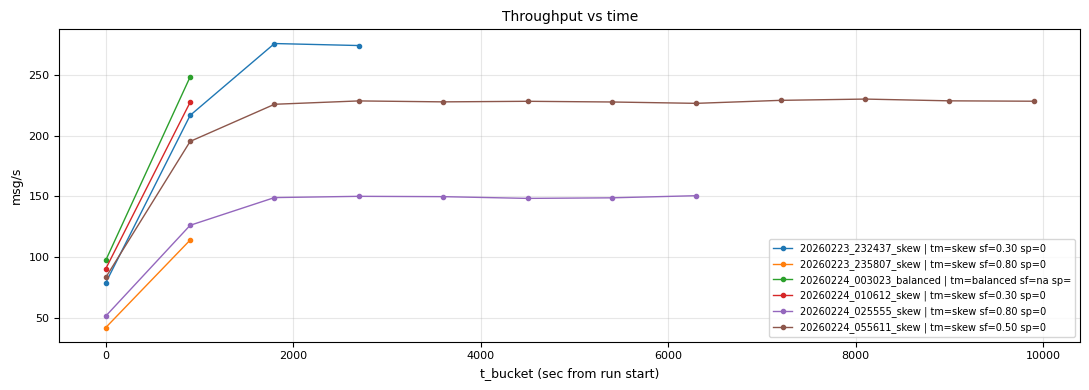

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_throughput.pdf


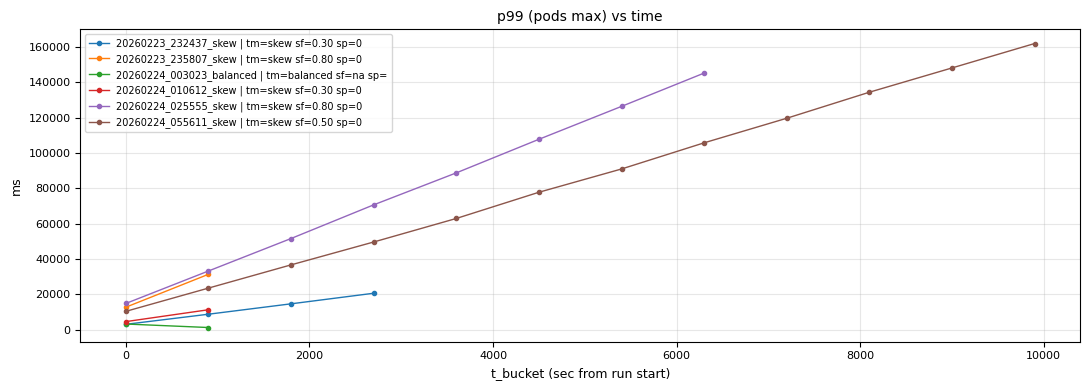

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_p99_pods_max.pdf


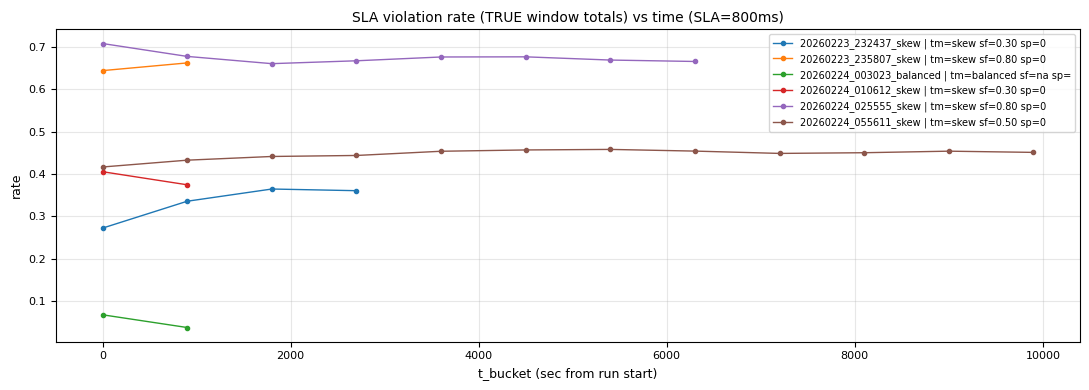

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_violation_true_window.pdf


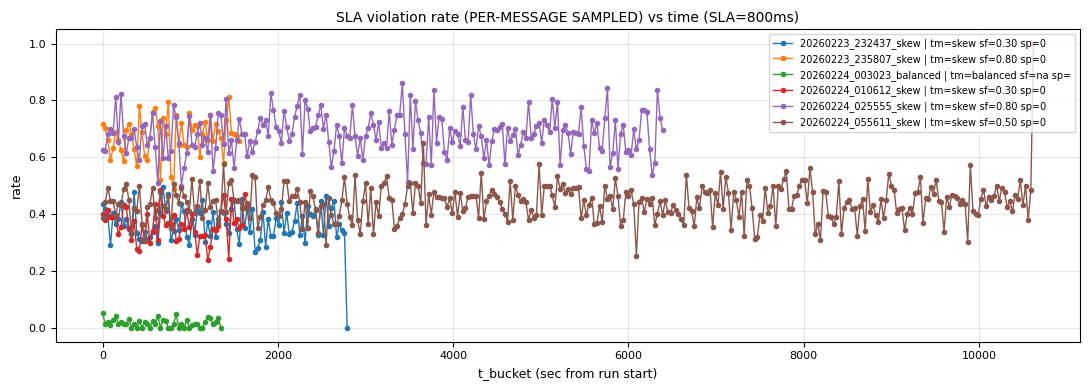

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/permsg_lines_violation.pdf


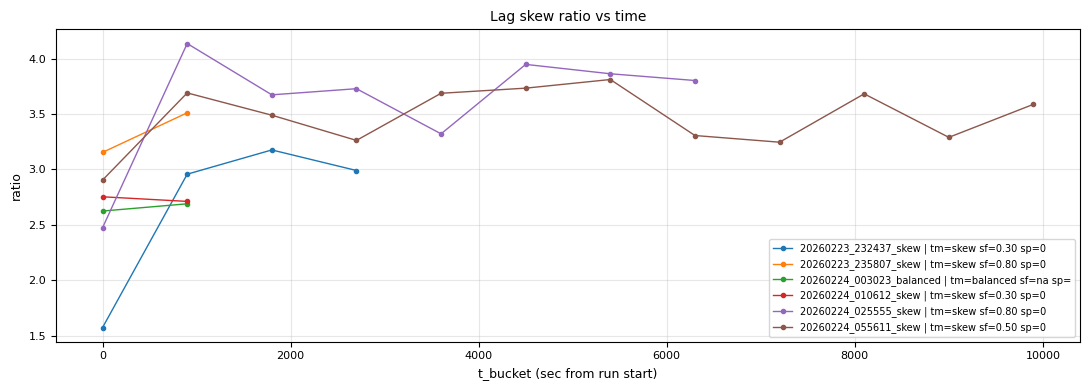

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_lag_skew_ratio.pdf


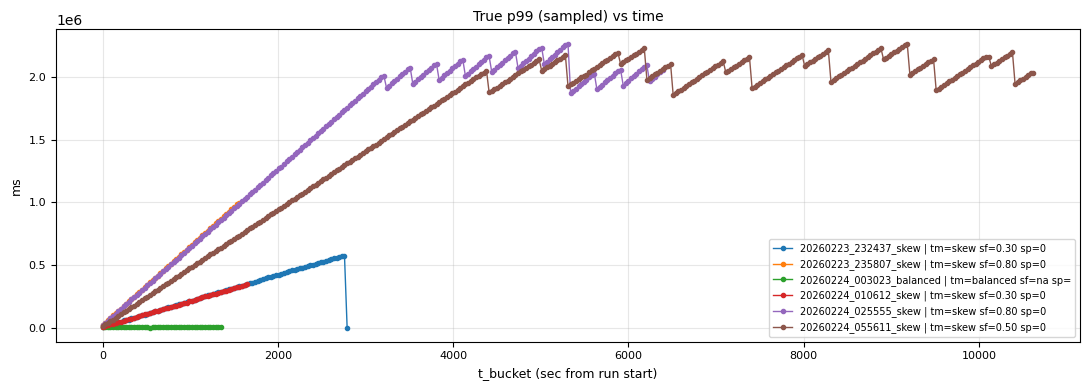

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_true_p99.pdf


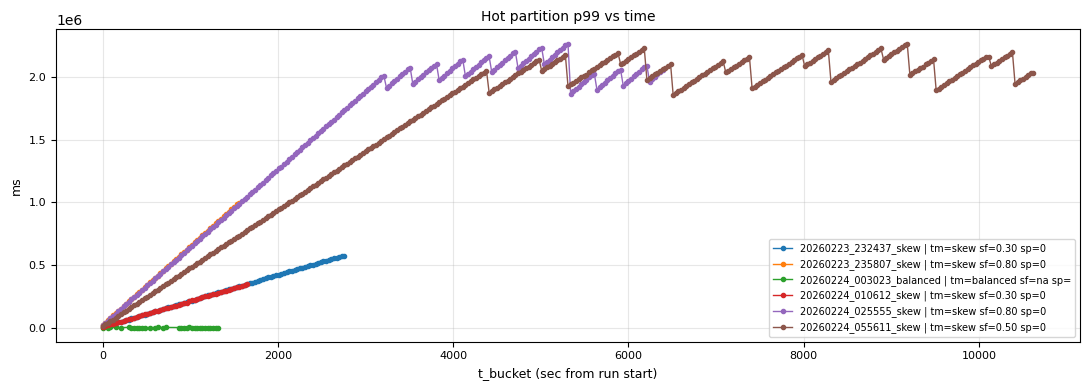

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_hot_partition_p99.pdf


In [8]:
# =========================
# Line plots (compare runs by t_bucket)
# =========================
def line_compare(metric: str, title: str, ylab: str, out_pdf: str):
    if hybrid_ts.empty:
        print('[WARN] no time series to plot')
        return
    if metric not in hybrid_ts.columns:
        print('[WARN] metric not found:', metric)
        return

    fig = plt.figure(figsize=(11, 4))
    ax = fig.add_subplot(111)

    for label, g in hybrid_ts[['t_bucket','label',metric]].groupby('label'):
        g = g[['t_bucket', metric]].dropna()
        g = g.sort_values('t_bucket')
        if len(g) == 0:
            continue
        if len(g) < 2:
            print(f"[INFO] {metric}: only {len(g)} point for {label} (will look like a dot)")
        ax.plot(g['t_bucket'], g[metric], label=label, marker='o', markersize=3, linewidth=1)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('t_bucket (sec from run start)', fontsize=9)
    ax.set_ylabel(ylab, fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    out = OUT_DIR / out_pdf
    fig.savefig(out, dpi=200)
    plt.show()
    plt.close(fig)
    print('[OK] saved', out)

# Truth from consumer_metrics
line_compare('throughput', 'Throughput vs time', 'msg/s', 'hybrid_lines_throughput.pdf')
line_compare('p99_pods_max_ms', 'p99 (pods max) vs time', 'ms', 'hybrid_lines_p99_pods_max.pdf')
line_compare('viol_rate', f'SLA violation rate (TRUE window totals) vs time (SLA={SLA_MS}ms)', 'rate', 'hybrid_lines_violation_true_window.pdf')
line_compare('true_viol_rate', f'SLA violation rate (PER-MESSAGE SAMPLED) vs time (SLA={SLA_MS}ms)', 'rate', 'permsg_lines_violation.pdf')
line_compare('lag_skew_ratio', 'Lag skew ratio vs time', 'ratio', 'hybrid_lines_lag_skew_ratio.pdf')

# From per-message (sampled)
line_compare('true_p99_ms', 'True p99 (sampled) vs time', 'ms', 'hybrid_lines_true_p99.pdf')
line_compare('hot_part_p99_ms', 'Hot partition p99 vs time', 'ms', 'hybrid_lines_hot_partition_p99.pdf')


In [40]:
# Quick summary view
cols = [
    'run_id','traffic_mode','skew_fraction','skew_partitions',
    'throughput_mean_msg_s','p99_pods_max_mean_ms','viol_rate_mean','lag_skew_ratio_mean',
    'hot_consumer','hot_consumer_p99_mean_ms',
    'hot_partition','hot_partition_p99_mean_ms','permsg_n_samples','true_p99_mean_ms'
]
cols = [c for c in cols if c in hybrid_summary.columns]
hybrid_summary[cols].sort_values(['traffic_mode','skew_fraction'], na_position='last')

,run_id,traffic_mode,skew_fraction,skew_partitions,throughput_mean_msg_s,p99_pods_max_mean_ms,viol_rate_mean,lag_skew_ratio_mean,hot_consumer,hot_consumer_p99_mean_ms,hot_partition,hot_partition_p99_mean_ms,permsg_n_samples,true_p99_mean_ms
2,20260224_003023_balanced,balanced,NaN,,172.825000,2170.817500,0.052286,2.657179,consumer-sts-3,9.321043e+02,58,1.776872e+02,3966,8.074549e+02
0,20260223_232437_skew,skew,0.3,0,211.337500,11717.363500,0.333313,2.674226,consumer-sts-0,2.886470e+05,0,2.915008e+05,7734,2.883312e+05
3,20260224_010612_skew,skew,0.3,0,158.866668,7883.362500,0.390058,2.732430,consumer-sts-5,1.734349e+05,0,1.748245e+05,4571,1.746718e+05
1,20260223_235807_skew,skew,0.8,0,77.850000,21989.026000,0.653573,3.333158,consumer-sts-3,5.030184e+05,0,5.100653e+05,2342,5.099600e+05
4,20260224_025555_skew,skew,0.8,0,134.139584,79748.669375,0.675549,3.619388,consumer-sts-6,1.529961e+06,0,1.532127e+06,9683,1.532015e+06


In [41]:
run_id = "20260224_003023_balanced"
run_dir = RESULTS_ROOT / run_id

# rebuild the two time series directly
ts_m, pod_summ = build_ts_truth(run_dir, BUCKET_SEC)   # consumer_metrics truth
lat = load_per_message_run(run_dir)
ts_p, part_summ = build_partition_metrics_from_permsg(lat, BUCKET_SEC, SLA_MS)

print("ts_m buckets:", ts_m["t_bucket"].nunique(), "min/max", ts_m["t_bucket"].min(), ts_m["t_bucket"].max())
print("ts_p buckets:", ts_p["t_bucket"].nunique(), "min/max", ts_p["t_bucket"].min(), ts_p["t_bucket"].max())

common = set(ts_m["t_bucket"]).intersection(set(ts_p["t_bucket"]))
print("common buckets:", len(common))

ts_m buckets: 46 min/max 0 1350
ts_p buckets: 46 min/max 0 1350
common buckets: 46


In [42]:
run_id = "20260224_003023_balanced"
hybrid_ts[hybrid_ts.run_id==run_id][["t_bucket","throughput"]].head(10)
hybrid_ts[hybrid_ts.run_id==run_id]["throughput"].isna().sum()

44

In [43]:
run_dir = RESULTS_ROOT / "20260224_003023_balanced"
m = load_consumer_metrics_run(run_dir)

print("rows:", len(m))
print("columns:", list(m.columns))

# check msg_rate_window parsing
x = m["msg_rate_window"]
print("raw type:", x.dtype)
print("raw sample:", x.head(8).tolist())

x_num = pd.to_numeric(x, errors="coerce")
print("numeric non-NaN:", x_num.notna().sum(), "of", len(x_num))
print("numeric sample:", x_num.dropna().head(8).tolist())

rows: 368
columns: ['pod', 'traffic_mode', 'topics', 'window_total', 'window_viol', 'msg_rate_window', 'lat_window_seconds', 'lat_count_window', 'lat_p95_ms', 'lat_p99_ms', 'cpu_percent', 'mem_percent', 'uptime_sec', 'total_lag', 'max_lag', 'lag_skew_ratio', 'consumed_total', '__file']
raw type: float64
raw sample: [7.516667, 25.916667, 36.3, 35.7, 36.183333, 36.266667, 34.75, 34.183333]
numeric non-NaN: 368 of 368
numeric sample: [7.516667, 25.916667, 36.3, 35.7, 36.183333, 36.266667, 34.75, 34.183333]


In [44]:
ts_m.head()

,t_bucket,throughput,p99_pods_max_ms,p99_pods_med_ms,viol_rate,lag_skew_ratio
0,0,97.283333,3163.423,2790.6565,0.067329,2.624448
1,30,NaN,NaN,NaN,NaN,NaN
2,60,NaN,NaN,NaN,NaN,NaN
3,90,NaN,NaN,NaN,NaN,NaN
4,120,NaN,NaN,NaN,NaN,NaN
